In [1]:
#Law of Large numbers and Central Limit Theorem

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, expon, norm, laplace,binom,geom, multivariate_normal as mvn

In [2]:
m=0
v=1

xvals = norm.rvs(m,v,size=10)
np.mean(xvals)

np.float64(1.0516945996256721)

In [3]:
#Different answer for each run
m=0
v=1

xvals = norm.rvs(m,v,size=10)
np.mean(xvals)

np.float64(-0.110861283531526)

In [4]:
#np.mean( )  is adding all values and deividing by N
m=0
v=1


xvals = norm.rvs(m,v,size=10)
np.mean(xvals),np.sum(xvals)/len(xvals)

(np.float64(-0.4659101658670431), np.float64(-0.4659101658670431))

In [5]:
#Increasing variences
m=0
v=100

xvals = norm.rvs(m,v,size=10)
np.mean(xvals)

np.float64(-44.527705583799026)

In [6]:
#Adding more samples
m=0
v=100

xvals = norm.rvs(m,v,size=1000000)
np.mean(xvals)

np.float64(0.08944908836522579)

In [11]:
# We can slo use LLN to estimate functions of expected values called the "Sample Varience"
m=0
v=100

xvals = norm.rvs(m,v,size=1000)
m_est=np.mean(xvals)
v_est=np.sum(xvals-m_est)**2/len(xvals)
print(m_est,v_est)

-7.780449024079179 4.187601851049703e-27


In [10]:
# We can slo use LLN to estimate functions of expected values called the "Sample Varience"
m=0
v=100

xvals = norm.rvs(m,v,size=10000000)
m_est=np.mean(xvals)
v_est=np.sum(xvals-m_est)**2/len(xvals)
print(m_est,v_est)

-0.02461264798578447 1.885233620642261e-24


In [14]:
# 3 way to compute P(1<=X<=2)
m=0
v=1

xvals = norm.rvs(m,v,size=10000000)

# 
count =0
for x in xvals:
    if x>=1 and x<=2:
        count+=1
print(count/len(xvals
                ))
np.mean((xvals>=1)&(xvals<=2))

0.135793


np.float64(0.135793)

In [15]:
norm.cdf(2)-norm.cdf(1)

np.float64(0.13590512198327787)

In [16]:
from scipy.integrate import quad

def f(x):
    Z=(2*np.pi)**0.5
    return np.exp(-x**2/2)/Z

quad(f,1,2)

(0.13590512198327787, 1.508849955903256e-15)

Text(0.5, 0, 'x')

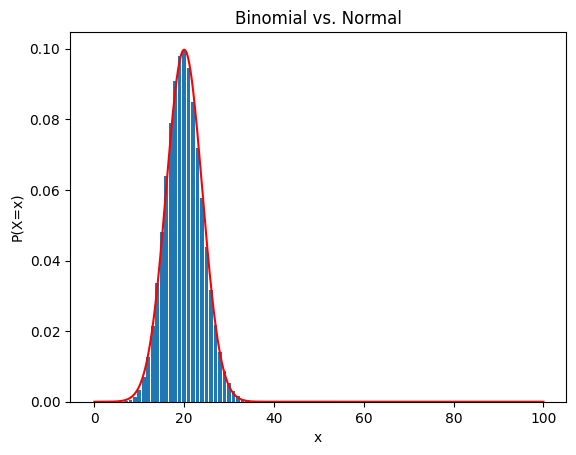

In [18]:
#CLT -Lets compare uniform and normal
n=100
p=0.2

xvals=np.arange(100)
yvals= binom.pmf(xvals,n=n,p=p)
plt.bar(xvals,yvals)

m=p*n
v=p*(1-p)*n

xvals2=np.linspace(0,100,1000)
yvals2=norm.pdf(xvals2,m,v**0.5)

plt.plot(xvals2,yvals2,c='red')

plt.title('Binomial vs. Normal')
plt.ylabel('P(X=x)')
plt.xlabel('x')

theorotical mean: 50.0
theorotical Variance: 8.333333333333332
Sample mean:  50.02460356414122
sample variance: 8.382801026614725


Text(0.5, 0, 'x')

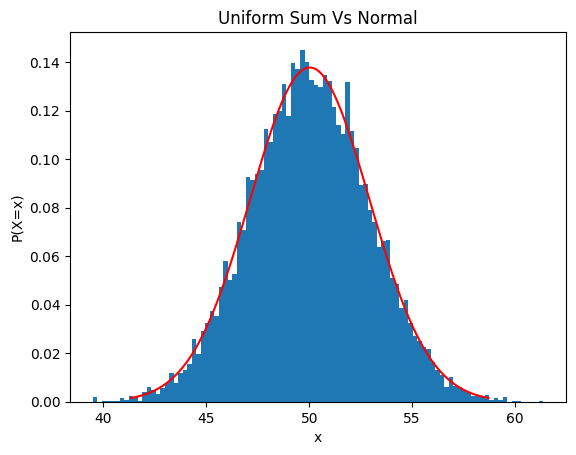

In [20]:
#CLT - Lets compare uniform and normal

#unlike th eprevious example, this is based on SAMPLES

N= 100
M =10000
samples= np.zeros(M)
for i in range(M):
    sample= uniform.rvs(size=N)
    samples[i]=np.sum(sample)

#theorotical mean of U (a,b)= 0.5 (a+b)
#theorotical mean of sum = 0.5*N
#theorotical variance 0f U(a,b)=(1/12)*(b-a)^2
#theorotical variance of sum =(1/12)*N

print('theorotical mean:',0.5*N)
print('theorotical Variance:',(1/12)*N)

m=np.mean(samples)
v=np.var(samples) #np.sum((samples-m )**2)/len(samples)
s=np.std(samples) #v**.5

print('Sample mean: ',m)
print('sample variance:',v)

#instead of plotting the true distribution of U_1+U_2+....+U_N, lest plot the histogram (approximate distribution). We set density =True so its normalised(otherwise, it shows counts)

plt.hist(samples,bins=100,density=True)

xvals=np.linspace(m-3*s,m+3*s,10000)
yvals=norm.pdf(xvals,m,s)
plt.plot(xvals,yvals,c='red')

plt.title('Uniform Sum Vs Normal')
plt.ylabel('P(X=x)')
plt.xlabel('x')